In [ ]:
import jax
from jax import config
import jax.numpy as jnp
from jax import Array
import numpy as np
config.update("jax_enable_x64", True)  # do this at the very top

import matplotlib.pyplot as plt

import mplcyberpunk
plt.style.use("cyberpunk")

plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]  # matches LaTeX default


from gaussed.domains import Euclidean
from gaussed.domains.index import IndexDomain
from gaussed.codomains import Codomain

from gaussed.gp.gp_ops.base import KernelSpec, FunSpec
from gaussed.gp.gp_ops.point_eval import Eval
from gaussed.gp.gp_ops.partial import Partial
from gaussed.gp.gp_ops.grad import Grad
from gaussed.gp.gp_ops.affine import Affine
from gaussed.gp.gp_ops.weighted_eval import WeightedEval
from gaussed.gp.gp_ops.probe import Probe, ProbeStack, as_stack
from gaussed.gp.gp_ops.linearise import Linearise

from gaussed.gp.kernels.rbf import RBFKernel, RBFParams
from gaussed.gp.kernels.matern import MaternKernel, MaternParams
from gaussed.gp.kernels.imq import IMQKernel, IMQParams
from gaussed.gp.kernels.delta import DeltaKernel, DeltaParams
from gaussed.gp.kernels.stacked import StackedKernel
from gaussed.gp.kernels.coregional import CoregionParams, CoregionalKernel
from gaussed.gp.means import ZeroMeanFun
from gaussed.gp.base import GP, PosteriorGP

from gaussed.model import GPModel
from gaussed.utils.shape_helpers import pack_ev2mat

from gaussed.backends.base import ExactBackend, BasisBackend
from gaussed.backends.reps.basis_rep import BasisRep
from gaussed.backends.solvers.linear_solver import SolverFns
from gaussed.backends.solvers.cholesky import (
    chol_solve_hook,
    chol_sqrt_hook,
    chol_logdet_hook,
)
from gaussed.backends.solvers.svd import svd_solve_hook, svd_sqrt_hook, svd_logdet_hook

from gaussed.likelihoods.gaussian import GaussianLikelihood
from gaussed.likelihoods.gaussian_noise import DiagonalNoise
from gaussed.sed.base import *

from gaussed.backends.basis.spectral_basis import LaplaceBasis
from gaussed.backends.reps.basis_rep import BasisRep
from gaussed.linops.constructors import DenseGramConstructor, ColaConstructor

solver_fns = SolverFns(svd_solve_hook(), svd_sqrt_hook(), svd_logdet_hook())


In [2]:
# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
mat_params = MaternParams(lengthscale=jnp.array(0.), amplitude=jnp.array(1.0), nu=1.5)
kernel   = MaternKernel(mat_params)
backend = ExactBackend(solverfns=solver_fns) 

gp = GP(domain, codomain, mean, kernel, backend)

from gaussed.gp.gp_ops.base import KernelSpec, BasisSpec, FunSpec, OpContext

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(-3.0, 3.0, 10).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.1
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(), fnl=Eval(Xtr))
Xt = jnp.linspace(-5.0, 5.0, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))


In [13]:
# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
mat_params = MaternParams(lengthscale=jnp.array(.2), amplitude=jnp.array(3.0), nu=1.5)
kernel   = MaternKernel(mat_params)
backend = BasisBackend(solverfns=solver_fns, basis_family=LaplaceBasis(1), m_per_dim=40)

gp = GP(domain, codomain, mean, kernel, backend)

from gaussed.gp.gp_ops.base import KernelSpec, BasisSpec, FunSpec, OpContext

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(0.1, 0.9, 10).reshape(-1, 1)
y_clean = jnp.sin(jnp.pi * Xtr).squeeze()
noise = 0.1
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(), fnl=Eval(Xtr))
Xt = jnp.linspace(0.01, 0.99, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

print(backend.linop_constructor)

DenseGramConstructor()


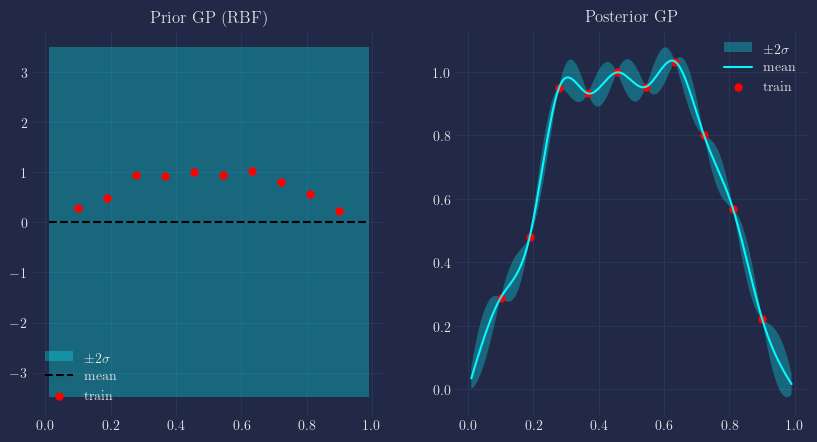

In [14]:

# --- Model / condition ---
lik = GaussianLikelihood()
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (RBF)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="$\\pm 2 \\sigma$")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="$\\pm2\\sigma$")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# plt.tight_layout()
plt.show()
